# Phase retrieval demo

Reconstruction of the simulated diffraction pattern in `sample_lena.mat` with dpGPS-F (500 random
starts, 3000 iterations each), followed by the evaluation of the reconstructions: alignment,
errors, pairwise distances, the phase retrieval transfer function (PRTF) and the eigenmodes.

Measured data are prepared in the same way: the intensity is fftshifted (zero frequency at the
centre) with NaN for missing pixels, and dRAAR and dpGPS need it in photon counts.

In [1]:
import math
import os
import time

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  # GPUs to use (set before importing torch)

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.io import loadmat, savemat
from tqdm import tqdm

from phaseretrieval import PRTF, PSD, EigenMode, PairwiseDistance, PhaseRetrieval, SubpixelAlignment

_ = torch.manual_seed(0)  # seed of the random initial phases

## Data

`sample_lena.mat` holds the fftshifted `intensity` with NaN for missing pixels, the ground truth
`sample` and its `support`.

pattern size: (512, 512), total intensity: 1.37e+06 photons


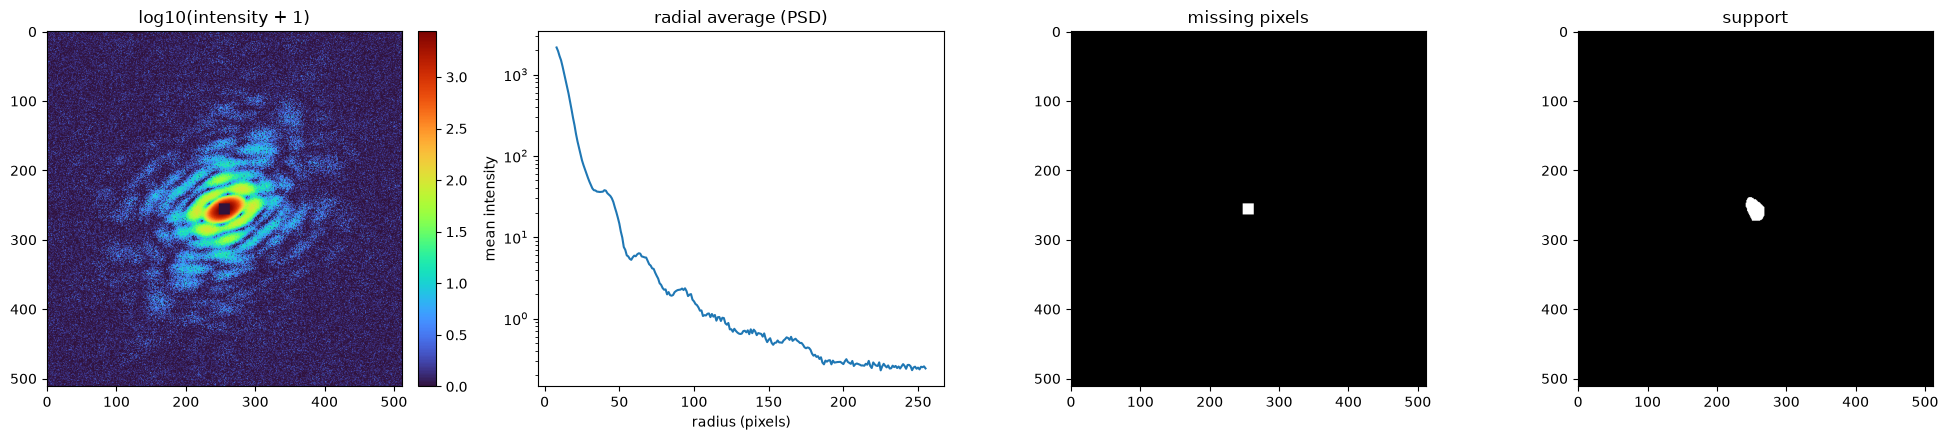

In [2]:
data = loadmat("sample_lena.mat")
intensity = data["intensity"]
missing = np.isnan(intensity)
intensity[missing] = 0
support = data["support"] > 0
ground_truth = np.clip(data["sample"] * support, 0, None)
print(f"pattern size: {intensity.shape}, total intensity: {intensity.sum():.3g} photons")

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
image = axes[0].imshow(np.log10(intensity + 1), cmap="turbo")
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_title("log10(intensity + 1)")
axes[1].semilogy(PSD(intensity, mask=missing))
axes[1].set(xlabel="radius (pixels)", ylabel="mean intensity", title="radial average (PSD)")
axes[2].imshow(missing, cmap="gray")
axes[2].set_title("missing pixels")
axes[3].imshow(support, cmap="gray")
axes[3].set_title("support")
plt.tight_layout()
plt.show()

## Phase retrieval

The algorithms take tensors of shape `(1, 1, H, W)` with k-space data *not* fftshifted (zero
frequency at index `(0, 0)`). `help(PhaseRetrieval)` describes the algorithms and their
parameters; a tuple `(ratio_0, value_0, ratio_1, value_1, ...)` changes a parameter to
`value_k` after the fraction `ratio_k` of the iterations. The same dictionary is passed to the
constructor and to the call, which ignore the parameters of other algorithms.

In [3]:
def to_tensor(x):
    return torch.from_numpy(x.astype(np.float32))[None, None]


amplitude = to_tensor(np.sqrt(np.fft.ifftshift(intensity)))
unknown = to_tensor(np.fft.ifftshift(missing))
support_tensor = to_tensor(support)

n_seeds = 500  # number of reconstructions
batch_size = 100  # reconstructions per call
n_iter = 3000  # iterations per reconstruction

params = {
    "algorithm": "dpGPS-F",  # HIO, RAAR, gRAAR, dRAAR, GPS-R, GPS-F, dpGPS-R or dpGPS-F
    "error": "R",  # R-factor (R) or Poisson negative log-likelihood (NLL)
    "shrinkwrap": False,  # update the support with ShrinkWrap
    # HIO, RAAR, gRAAR, dRAAR
    "beta": 0.5,  # relaxation parameter
    "beta_type": "linear",  # const, linear or step (step as in the RAAR paper)
    "beta_lim": 1,  # final beta
    "boundary_push": 0,  # fraction of the iterations in the final boundary push stage
    # GPS, dpGPS
    "sigma": (0, 0.01, 0.4, 0.1, 0.7, 1),  # relaxation of the magnitude constraint
    "alpha_count": 10,  # number of stages of the frequency filter on the support constraint
    # GPS
    "t": 1,  # step of the proximal operator on the magnitude constraint
    "s": 0.8,  # step of the proximal operator on the support constraint
    # dRAAR, dpGPS
    "limit": 0.28,  # preconditioner limited to [1 - limit, 1 + limit]
    "deep": True,  # deep-learning preconditioner (otherwise a constant one)
    # ShrinkWrap
    "sigma_initial": 3,  # initial width of the Gaussian kernel (pixels)
    "sigma_limit": 1.5,  # final width
    "ratio_update": 0.01,  # relative decrease of the width per update
    "threshold": 0.1,  # threshold of the new support (relative to the maximum)
    "interval": 50,  # iterations between updates
}

iterator = PhaseRetrieval(amplitude, support_tensor, unknown, **params)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # the CPU is much slower
if torch.cuda.device_count() > 1:
    iterator = nn.DataParallel(iterator)  # split each batch over the GPUs
iterator = iterator.to(device)

100%|██████████| 5/5 [00:51<00:00, 10.34s/it]

500 reconstructions x 3000 iterations in 52 s


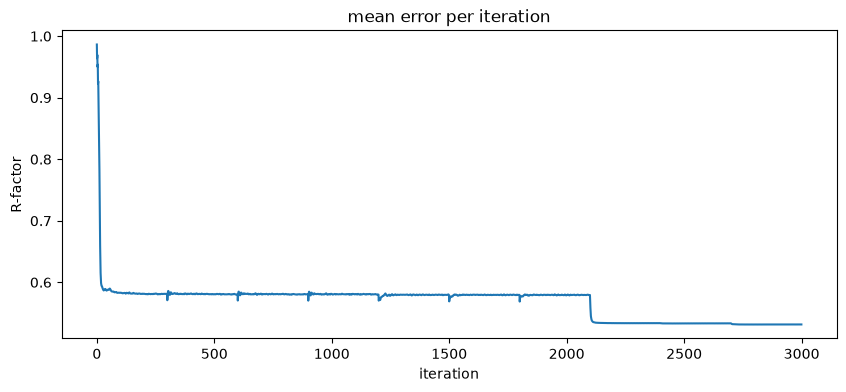

In [4]:
h, w = intensity.shape
objects = torch.zeros(n_seeds, 1, h, w)
error_path = torch.zeros(n_seeds, n_iter)
t_start = time.time()
for start in tqdm(range(0, n_seeds, batch_size)):
    n = min(batch_size, n_seeds - start)
    theta = torch.rand(n, 1, h, w) * 2 * math.pi
    initial_phase = torch.polar(torch.ones_like(theta), theta).to(device)
    output, path = iterator(n_iter, initial_phase, **params)
    objects[start : start + n], error_path[start : start + n] = output.cpu(), path.cpu()
elapsed = time.time() - t_start
print(f"{n_seeds} reconstructions x {n_iter} iterations in {elapsed:.0f} s")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(error_path.mean(dim=0))
ax.set(xlabel="iteration", ylabel="R-factor", title="mean error per iteration")
plt.show()

## Results

The reconstructions are sorted by their lowest error and aligned to the ground truth, allowing
subpixel shifts and the twin image (180-degree rotation). R-factors near 0.53 are at the noise
level of this pattern: the ground truth itself gives 0.54.

subpixel alignment: 100%|██████████| 500/500 [00:16<00:00, 30.44it/s]


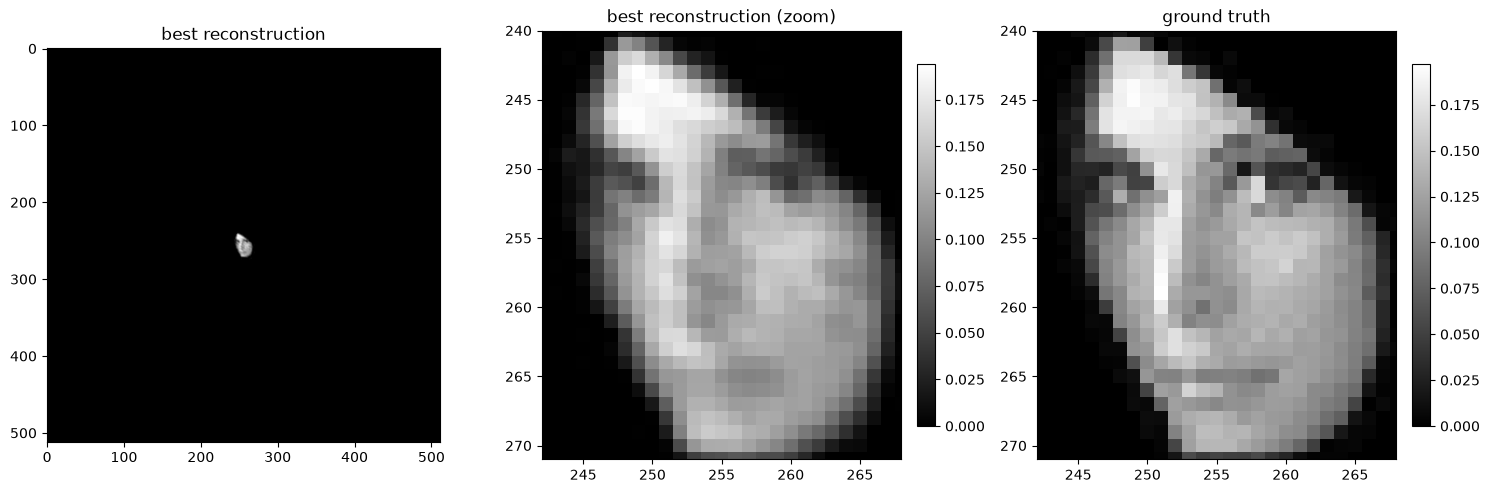

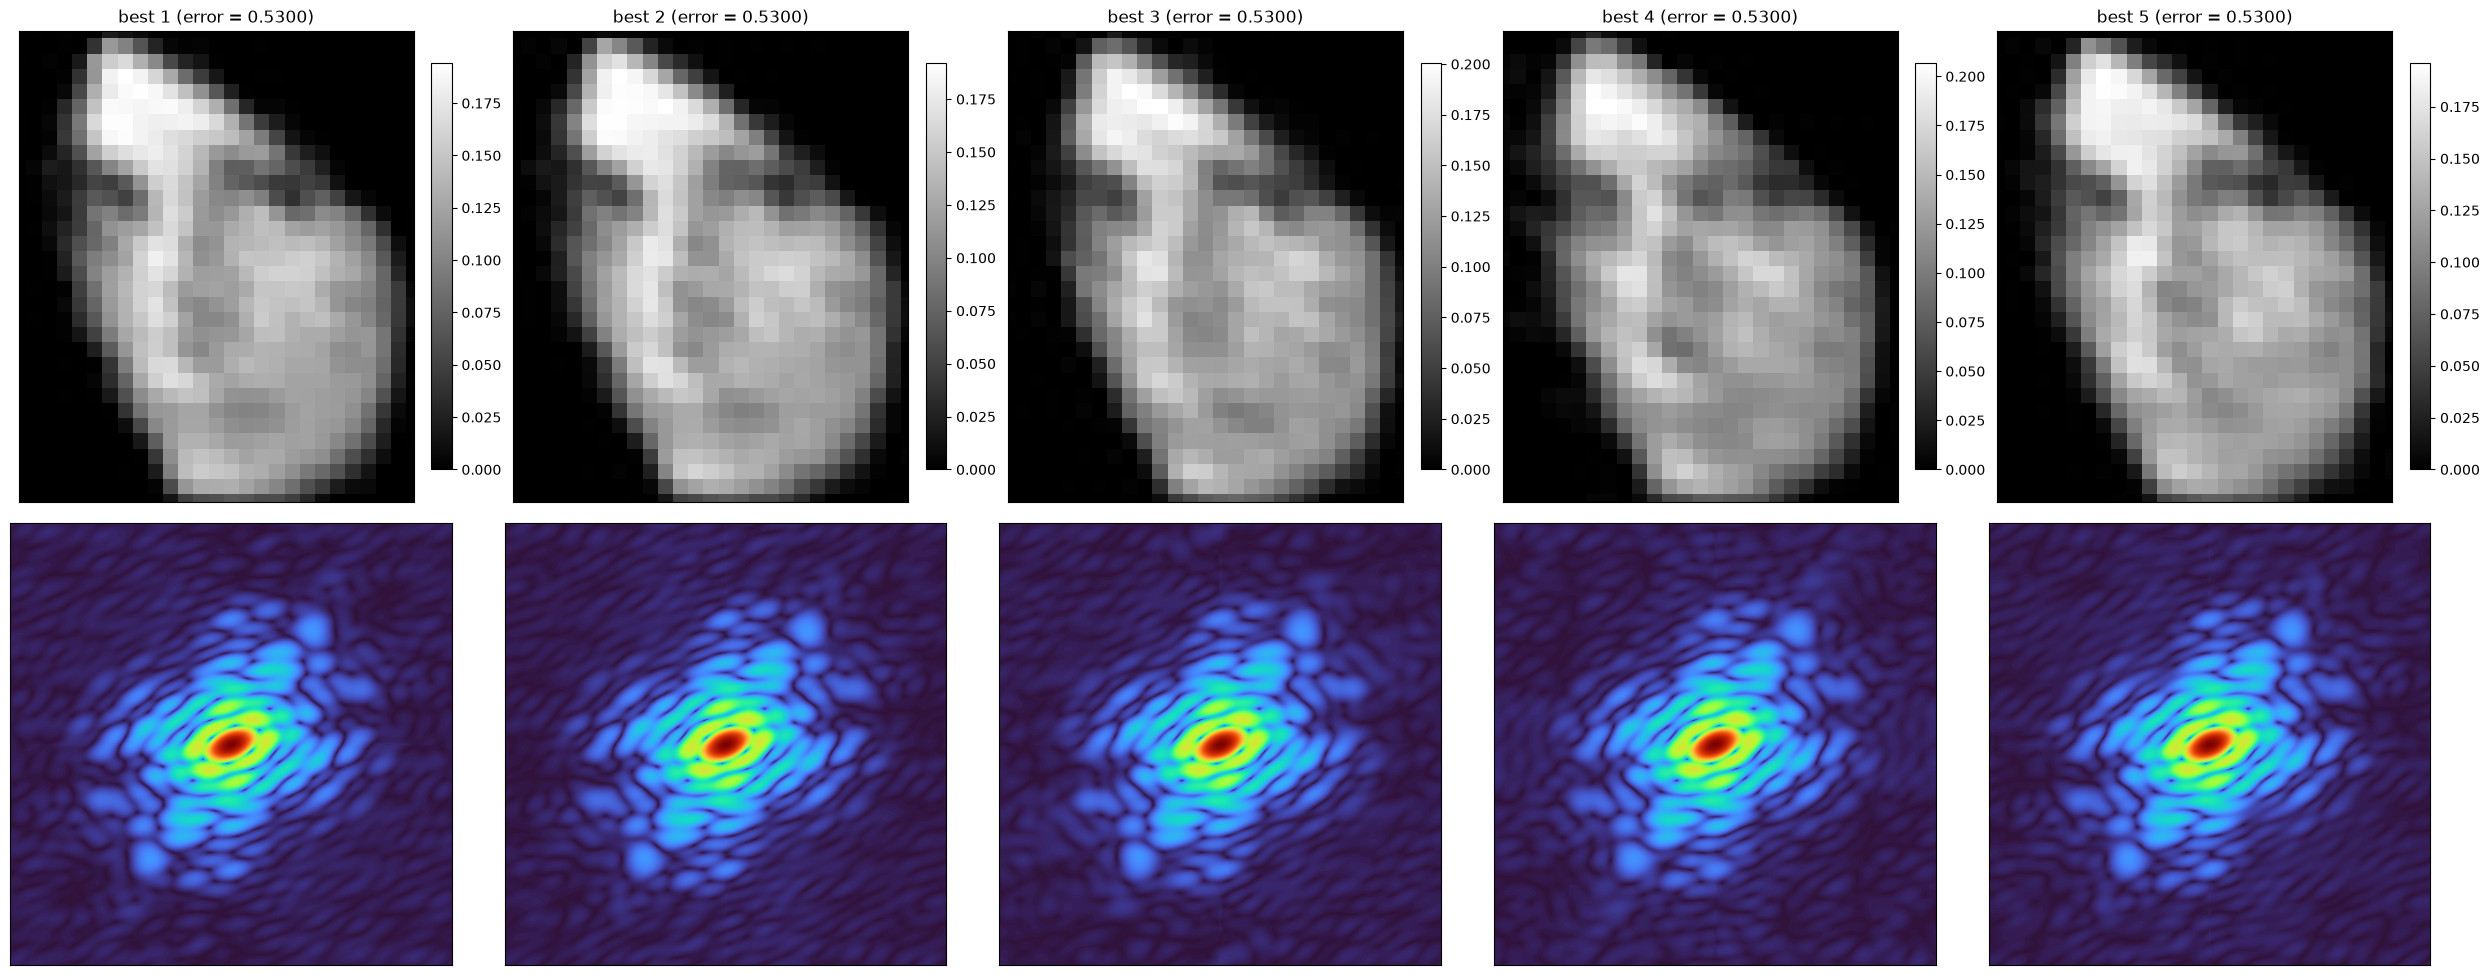

In [5]:
objects, error = SubpixelAlignment(
    objects[:, 0].numpy(),
    error=error_path.min(dim=1).values.numpy(),
    ref=ground_truth,
    subpixel=10,
)

rows, cols = np.nonzero(ground_truth > 0)
zoom = {"xlim": (cols.min(), cols.max()), "ylim": (rows.max(), rows.min())}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(objects[0], cmap="gray")
axes[0].set_title("best reconstruction")
for ax, obj, title in (
    (axes[1], objects[0], "best reconstruction (zoom)"),
    (axes[2], ground_truth, "ground truth"),
):
    image = ax.imshow(obj, cmap="gray")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set(title=title, **zoom)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for n, (top, bottom) in enumerate(axes.T):
    image = top.imshow(objects[n], cmap="gray")
    fig.colorbar(image, ax=top, fraction=0.046, pad=0.04)
    top.set(title=f"best {n + 1} (error = {error[n]:.4f})", xticks=[], yticks=[], **zoom)
    bottom.imshow(np.log(np.abs(np.fft.fftshift(np.fft.fft2(objects[n]))) + 1), cmap="turbo")
    bottom.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

## Reproducibility

Pairwise distances between the reconstructions, and the PRTF (the modulus of their mean Fourier
transform relative to the measured amplitude) with its radial average. The dotted lines mark the
PRTF levels 0.5 and 1/e.

pairwise distance: 100%|██████████| 124750/124750 [01:25<00:00, 1461.16it/s]


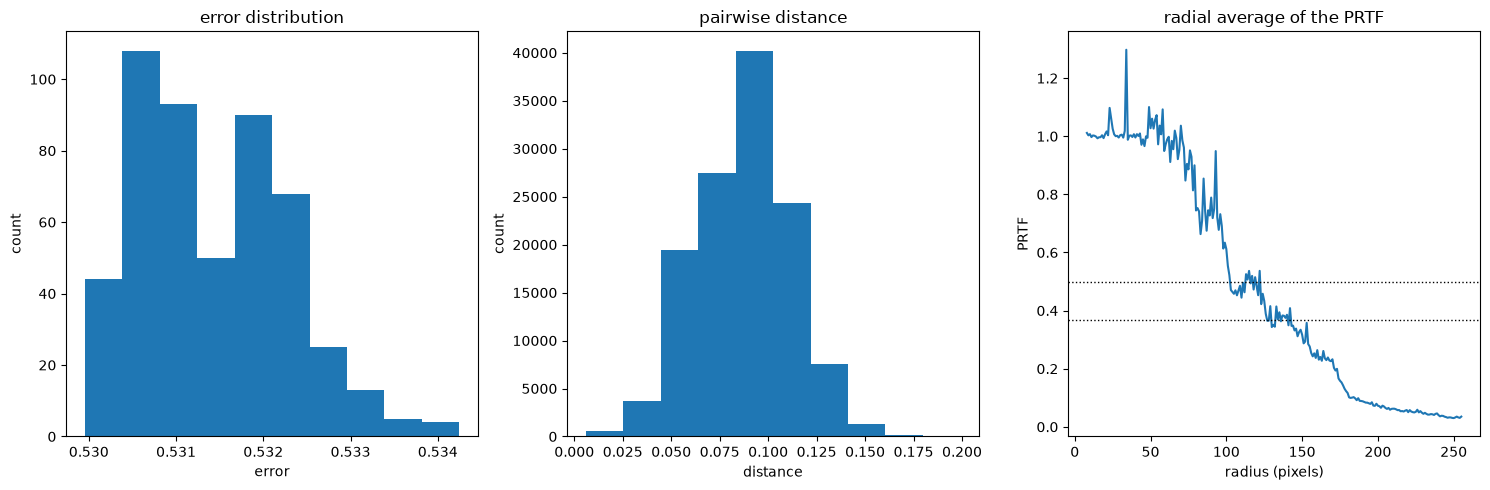

In [6]:
distances = PairwiseDistance(objects)
prtf = PRTF(objects, ref=np.sqrt(intensity), mask=missing)
prtf_psd = PSD(prtf, mask=missing)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].hist(error)
axes[0].set(xlabel="error", ylabel="count", title="error distribution")
axes[1].hist(distances)
axes[1].set(xlabel="distance", ylabel="count", title="pairwise distance")
axes[2].plot(prtf_psd)
for level in (0.5, 1 / math.e):
    axes[2].axhline(level, color="k", linestyle=":", linewidth=1)
axes[2].set(xlabel="radius (pixels)", ylabel="PRTF", title="radial average of the PRTF")
plt.tight_layout()
plt.show()

## Eigenmodes

The singular value decomposition of the aligned reconstructions (cropped to the region of the
object) separates the structure they share, carried by the first modes, from their variations.
The rank-`l` approximation of the set is the mean reconstruction projected onto the first `l`
modes.

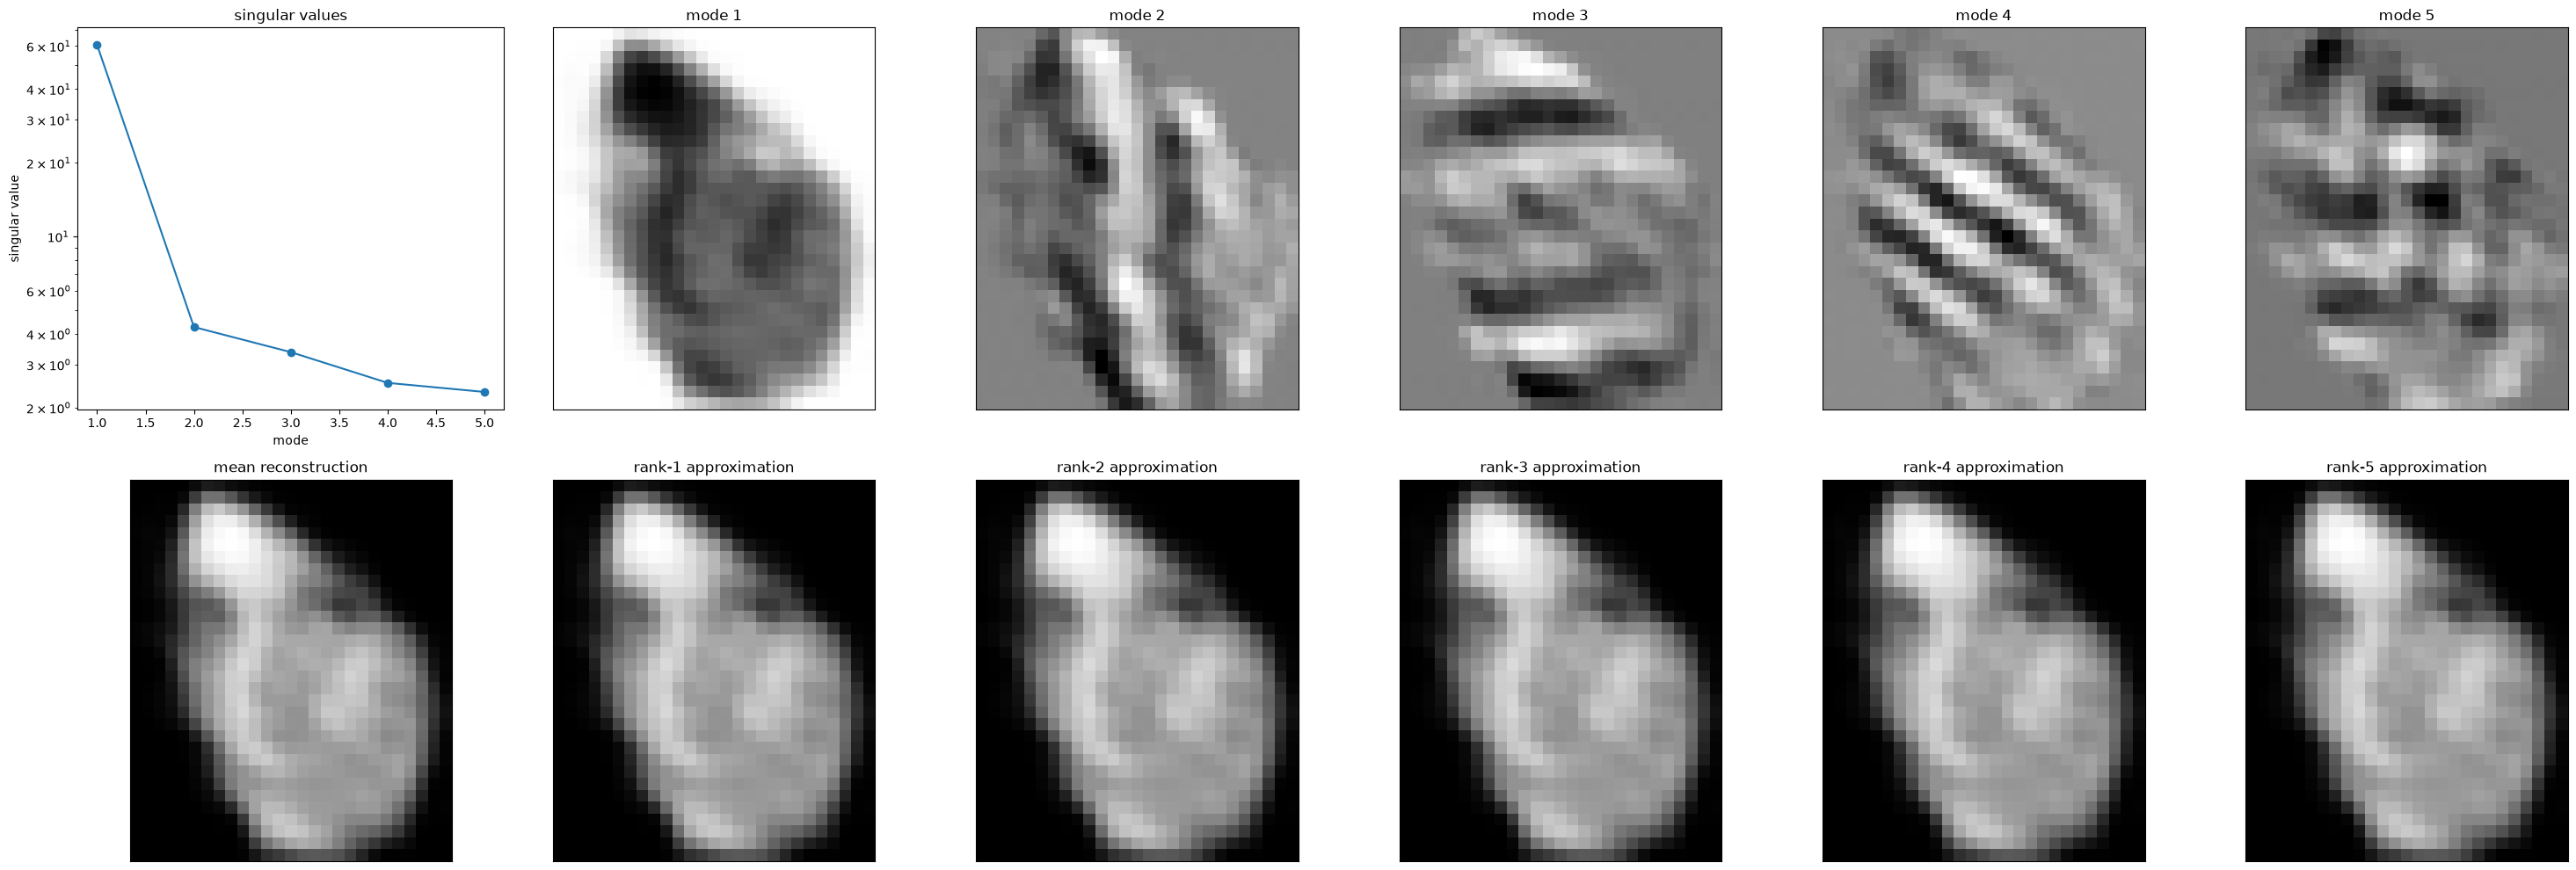

In [7]:
region = np.s_[:, rows.min() : rows.max() + 1, cols.min() : cols.max() + 1]
modes, singular, approx = EigenMode(objects[region], k=5)

fig, axes = plt.subplots(2, 6, figsize=(30, 10))
axes[0, 0].semilogy(np.arange(1, 6), singular, "o-")
axes[0, 0].set(xlabel="mode", ylabel="singular value", title="singular values")
axes[1, 0].imshow(objects[region].mean(axis=0), cmap="gray")
axes[1, 0].set(title="mean reconstruction", xticks=[], yticks=[])
for n in range(5):
    axes[0, n + 1].imshow(modes[n], cmap="gray")
    axes[0, n + 1].set(title=f"mode {n + 1}", xticks=[], yticks=[])
    axes[1, n + 1].imshow(approx[n], cmap="gray")
    axes[1, n + 1].set(title=f"rank-{n + 1} approximation", xticks=[], yticks=[])
plt.tight_layout()
plt.show()

## Saving

Set `save_results = True` to store the results in a MATLAB file.

In [8]:
save_results = False
save_dir = "./results"
save_name = "lena_face"

if save_results:
    os.makedirs(save_dir, exist_ok=True)
    savemat(
        os.path.join(save_dir, f"{save_name}_{time.strftime('%Y%m%d_%H%M')}.mat"),
        {
            "result": objects,
            "error": error,
            "info": params,
            "t_elap": elapsed,
            "dpair": distances,
            "prtf": prtf,
            "prtf_psd": prtf_psd,
        },
    )